# Modelo de Regresión Lineal para predecir el consumo de combustible MPG

HILDAURA CHIRINOS MORALES

se va  entrenar un modelo de regresión lineal que intente predecir el consumo de combustible de un automóvil, medido en millas por galón (mpg, variable numérica continua), con base en las características técnicas del vehículo: número de cilindros, cilindrada (displacement), potencia (horsepower), peso (weight), aceleración, año del modelo y región de origen.

## 1. Entendimiento del negocio

### 1.1 Descripción del dataset


El dataset Auto MPG, obtenido del repositorio UCI Machine Learning Repository, reúne información de 398 automóviles fabricados entre los años 1970 y 1982. Contiene datos relacionados con las características técnicas de cada vehículo, como el número de cilindros, la cilindrada, la potencia del motor, el peso, la aceleración, el año del modelo y el país de origen. Además, incluye la variable MPG (millas por galón), que representa el rendimiento o consumo de combustible del automóvil y será la variable que se buscará predecir mediante el modelo de regresión lineal.tiene 9 atributos

- mpg: consumo de combustible en millas por galón (variable objetivo)
- cylinders: número de cilindros del motor
- displacement: cilindrada del motor (pulgadas cúbicas)
- horsepower: potencia del motor (caballos de fuerza)
- weight: peso del vehículo (libras)
- acceleration: tiempo de aceleración de 0 a 60 mph (segundos)
- model_year: año del modelo (70 = 1970, ..., 82 = 1982)
- origin: región de origen del vehículo (1 = EE.UU., 2 = Europa, 3 = Japón)
- car_name: nombre del automóvil (identificador único, no se usa como variable predictora)


### 1.2 Objetivo


Entrenar un modelo de regresión lineal que permita predecir el consumo de combustible (`mpg`) de un automóvil a partir de sus características técnicas, e identificar cuáles de esas variables tienen mayor influencia sobre el consumo.

## 2. Entendimiento de los datos

### 2.1 Colección o lectura de datos

In [1]:
#librerias para el analisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

# El archivo original viene separado por espacios en blanco, sin encabezado
columnas = ["mpg", "cylinders", "displacement", "horsepower", "weight",
            "acceleration", "model_year", "origin", "car_name"]

ruta = r"C:\Users\pc\OneDrive\Escritorio\Mineria de datos\actividad en clase\auto-mpg.data" 

df = pd.read_csv(
    ruta,
    sep=r"\s+",
    names=columnas,
    na_values="?"
)

df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


El archivo `auto-mpg.data` no tiene encabezados y usa espacios como separador, con el nombre del auto entre comillas al final de cada fila. Se define manualmente el nombre de las columnas.

### 2.2 Descripción de datos

In [3]:
# Dimensiones del dataset numeros de filas y columnas 
print("Número de filas y columnas:", df.shape)

Número de filas y columnas: (398, 9)


In [4]:
# Se revisa el tipo de dato de cada columna (int, float, string) y cuantos valores no nulos tiene
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [5]:
# Estadísticas descriptivas de las variables numéricas (media, min, max, cuartiles)
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
# Distribucion de la variable categorica origin y del año de modelo
print("Origen (1=EEUU, 2=Europa, 3=Japon):")
print(df['origin'].value_counts())
print("\nRango de años de modelo:", df['model_year'].min(), "-", df['model_year'].max())

Origen (1=EEUU, 2=Europa, 3=Japon):
origin
1    249
3     79
2     70
Name: count, dtype: int64

Rango de años de modelo: 70 - 82


### 2.3 Exploración de datos
Se analiza visualmente la relación entre las variables predictoras y la variable objetivo (`mpg`), y la correlación entre variables numéricas.

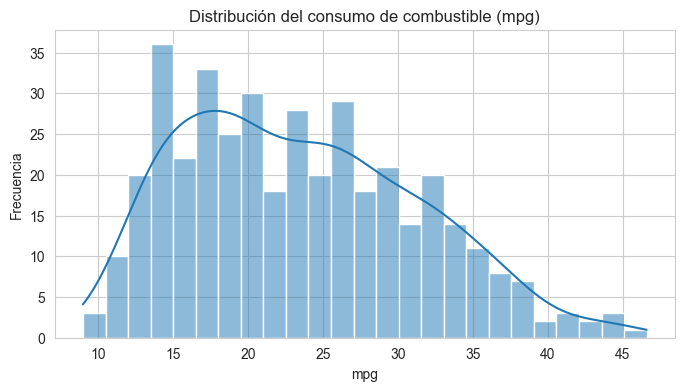

In [7]:
# se grafica la Distribución de la variable objetivo (mpg)
plt.figure(figsize=(8, 4))
sns.histplot(df["mpg"], kde=True, bins=25)
plt.title("Distribución del consumo de combustible (mpg)")
plt.xlabel("mpg")
plt.ylabel("Frecuencia")
plt.show()

En el gráfico se muestra que la mayoría de los autos tienen un consumo entre 15 y 25 mpg, con el pico más alto cerca de 14 mpg. También se observa que la distribución no es simétrica, sino que tiene una cola hacia la derecha, es decir, hay pocos autos con consumos altos (35-46 mpg) que estiran la distribución hacia ese lado.

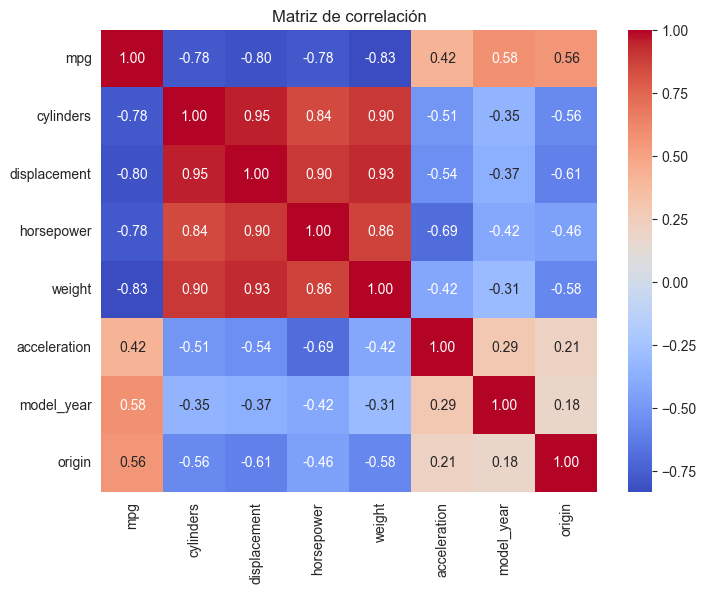

In [8]:
# Matriz de correlación entre variables numéricas
plt.figure(figsize=(8, 6))
corr = df.drop(columns=["car_name"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

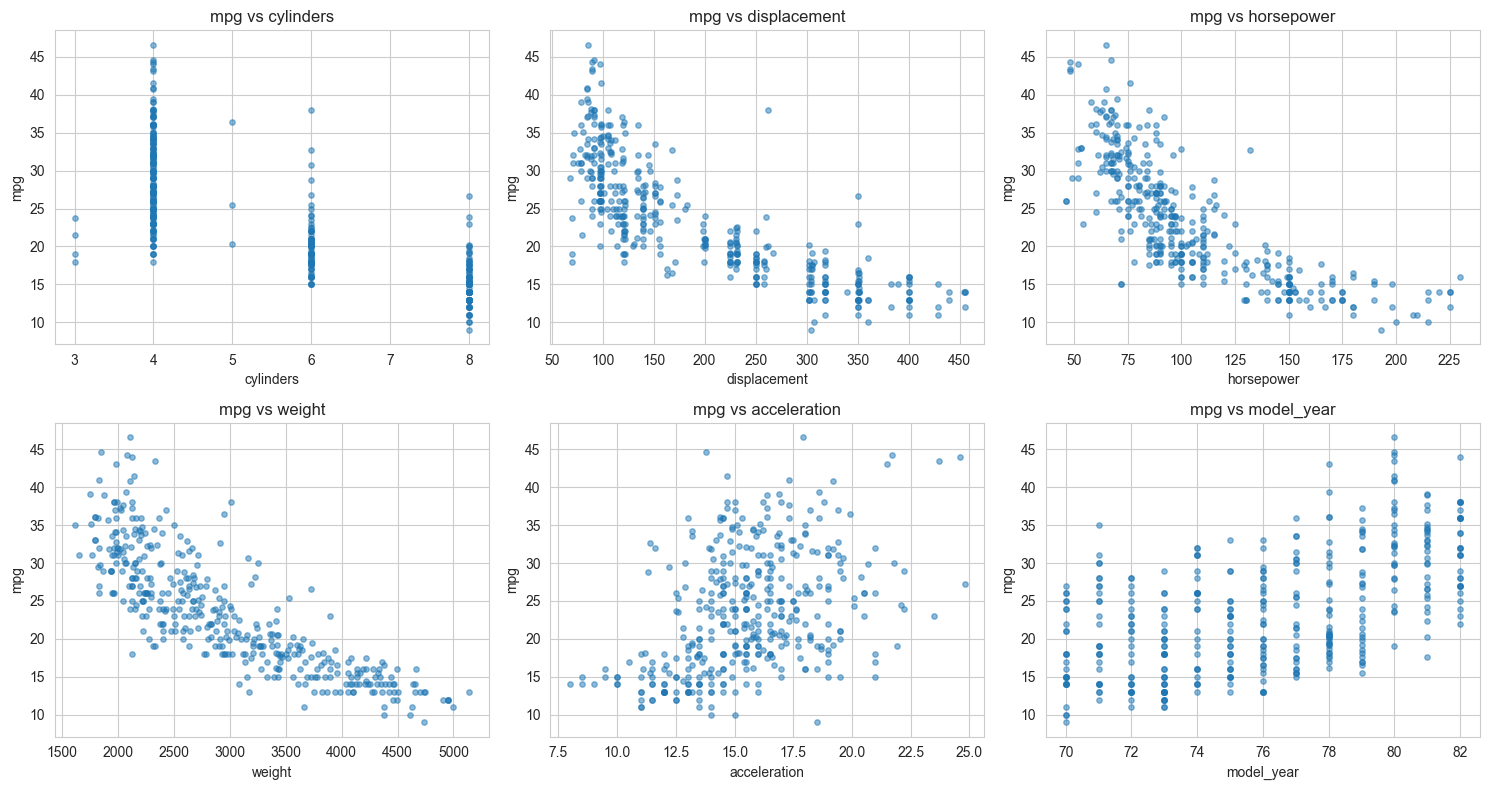

In [9]:
# aqui mostraremos la relacion de cada variable numerica con mpg que es el variable objetivo
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vars_pred = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

for ax, var in zip(axes.flat, vars_pred):
    ax.scatter(df[var], df['mpg'], alpha=0.5, s=15)
    ax.set_xlabel(var)
    ax.set_ylabel('mpg')
    ax.set_title(f'mpg vs {var}')

plt.tight_layout()
plt.show()

En estos gráficos se observa que cylinders, displacement, horsepower y weight tienen relación negativa con mpg (a mayor valor, menos consumo), mientras que model_year muestra relación positiva (autos más recientes rinden más). acceleration es la que menos patrón claro presenta.

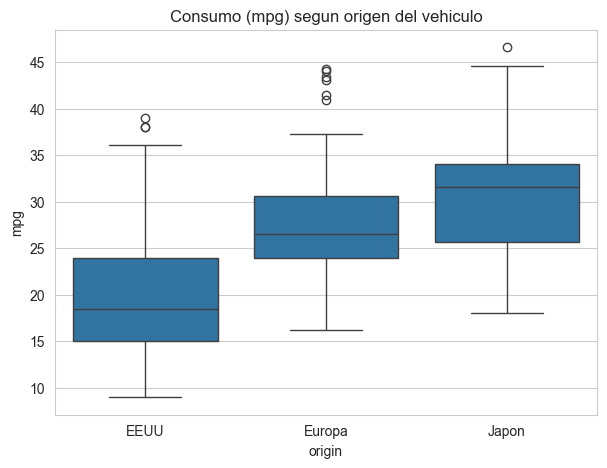

In [10]:
# mostramos un bloxplot de distribucion del consumo (mpg) por origen del vehiculo,para ver los valores atipicos
plt.figure(figsize=(7, 5))
sns.boxplot(x='origin', y='mpg', data=df)
plt.xticks([0, 1, 2], ['EEUU', 'Europa', 'Japon'])
plt.title("Consumo (mpg) segun origen del vehiculo")
plt.show()

### 2.4 Calidad de datos


In [11]:
# verificamos si hay valores faltantes como valores nulos 
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [12]:
# Verificamos si hay filas  con datos faltantes (todas en 'horsepower')
df[df['horsepower'].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


In [13]:
# Verificamos filas duplicadas
print("Cantidad de filas duplicadas:", df.duplicated().sum())

Cantidad de filas duplicadas: 0


In [14]:
# Verificamos que los tipos de datos todos sean en tipo int o float menos strin para el entrenamiento 

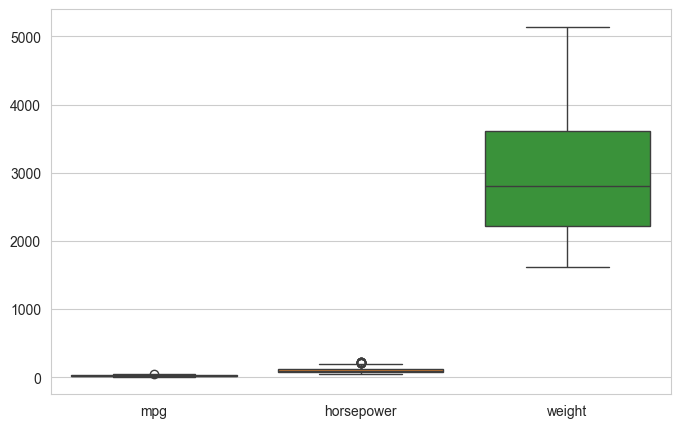

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[[
'mpg',
'horsepower',
'weight'
]])

plt.show()

El dataset tiene 398 registros y 9 columnas. La única columna con valores faltantes es horsepower, con 6 registros sin dato (representados originalmente con `?`). No se encontraron filas duplicadas. El boxplot muestra algunos valores altos en horsepower y weight, pero corresponden a autos reales de alto rendimiento o camionetas pesadas, no a errores de captura, por lo que se conservan. La columna car_name es un identificador de texto único por vehículo y no aporta valor predictivo, por lo que se descartará del modelo.

## 3. Preparación de datos

### 3.1 Selección y limpieza de datos


Se descarta car_name debido a que identifica el nombre comercial del automóvil y presenta una gran cantidad de categorías diferentes, las cuales no aportan significativamente al modelo de regresión lineal. También se imputan los 6 valores faltantes de horsepower con la mediana, para no perder esas filas.

In [16]:
# Se elimina la variable car_name debido a que representa el nombre comercial del automóvil y
# presenta una gran cantidad de categorías.
data = df.drop(columns=['car_name']).copy()


In [17]:
#La imputación mediante la mediana fue seleccionada debido a que la variable horsepower presenta una distribución ligeramente sesgada y la mediana es
#menos sensible a valores extremos que la media.
data['horsepower'] = data['horsepower'].fillna(data['horsepower'].median())

print("Valores nulos restantes:", data.isna().sum().sum())
data.head()

Valores nulos restantes: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### 3.2 Construir datos

Se crea `power_to_weight` (potencia/peso), un indicador de rendimiento del motor que no viene explícito en el dataset original.

In [18]:
# Se construye un atributo derivado: relacion potencia/peso, indicador del rendimiento
# del motor en relacion al peso del vehiculo, que puede influir en el consumo de combustible.
data['power_to_weight'] = data['horsepower'] / data['weight']
data[['horsepower', 'weight', 'power_to_weight']].head()

,horsepower,weight,power_to_weight
0,130.0,3504.0,0.037100
1,165.0,3693.0,0.044679
2,150.0,3436.0,0.043655
3,150.0,3433.0,0.043694
4,140.0,3449.0,0.040591


### 3.3 Integrar datos

No aplica: se trabaja con una única fuente (`auto-mpg.data`), por lo que no hay datos de otras tablas u orígenes que combinar.

### 3.4 Formatear datos

Se codifica `origin` con **One-Hot Encoding** (es una categoría sin orden jerárquico: EEUU/Europa/Japón, no un ranking) y se separan las variables predictoras (X) de la variable objetivo (y), dividiendo el dataset en entrenamiento y prueba.

In [19]:
# One-Hot Encoding de 'origin': representa el pais de origen (1=EEUU, 2=Europa, 3=Japon).
# Al no existir una relacion de orden entre las categorias, se evita que el modelo interprete
# incorrectamente que un valor numerico es 'mayor' que otro.
data = pd.get_dummies(data, columns=['origin'], drop_first=True)
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,power_to_weight,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,0.037100,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,0.044679,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,0.043655,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,0.043694,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,0.040591,False,False


Se separan las variables predictoras (X) de la variable objetivo (y), y se divide el dataset en un 80% para entrenamiento y un 20% para prueba.

In [20]:
# X: son las variables predicotras y la Y es la variable objetivo que es el consumo de combustible (mpg)
X = data.drop(columns=['mpg'])
y = data['mpg']

# se divide 80% en train y el 20% en test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 318 filas
Prueba: 80 filas


In [21]:
#verificamos las dimensiones de cada uno
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(318, 9)
(80, 9)
(318,)
(80,)


Se verifico que las dimensiones de los conjuntos resultantes sean consistentes: X_train y y_train deben tener el mismo número de filas, igual que X_test y y_test.

## 4. Modelado 

### 4.1 Selección de la técnica de modelado

Se utiliza **Regresión Lineal Múltiple**, ya que el objetivo es predecir un valor numérico continuo (`mpg`) a partir de varias variables de entrada.

### 4.2 Construcción del modelo

In [22]:
# Entrenamiento del modelo de regresion lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Coeficientes: cuanto cambia mpg por cada unidad de la variable, manteniendo las demas fijas
coef_df = pd.DataFrame({'variable': X.columns, 'coeficiente': modelo.coef_})
coef_df = coef_df.sort_values('coeficiente', key=abs, ascending=False)
print(f"Intercepto (b): {modelo.intercept_:.3f}\n")
coef_df

Intercepto (b): -1.601



,variable,coeficiente
6,power_to_weight,-491.371882
7,origin_2,2.711211
8,origin_3,2.584816
5,model_year,0.803777
2,horsepower,0.128158
0,cylinders,-0.076470
4,acceleration,-0.031083
1,displacement,0.012986
3,weight,-0.011715


Cada coeficiente indica cuánto cambia el `mpg` esperado al aumentar en una unidad esa variable, manteniendo las demás constantes. Como las variables tienen escalas distintas (por ejemplo, `weight` en libras vs `acceleration` en segundos), a continuación entrenamos también una versión con variables estandarizadas para poder comparar de forma justa la importancia relativa de cada una.

### 4.3 Predicciones

In [23]:
y_pred = modelo.predict(X_test)

# Comparacion de algunos valores reales vs predichos
comparacion = pd.DataFrame({'mpg_real': y_test.values, 'mpg_predicho': y_pred.round(2)})
comparacion.head(10)

,mpg_real,mpg_predicho
0,33.0,33.66
1,28.0,29.57
2,19.0,20.92
3,13.0,16.95
4,14.0,12.33
5,27.0,25.38
6,24.0,27.76
7,13.0,11.60
8,17.0,15.68
9,21.0,21.81


In [24]:
# Estandarizamos las variables para comparar la importancia relativa de cada coeficiente
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

modelo_lr_esc = LinearRegression()
modelo_lr_esc.fit(X_train_esc, y_train)

coef_esc = pd.Series(modelo_lr_esc.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Coeficientes estandarizados (ordenados por importancia):")
print(coef_esc)

Coeficientes estandarizados (ordenados por importancia):
weight            -9.832708
horsepower         4.745317
power_to_weight   -2.957546
model_year         2.891593
displacement       1.335241
origin_3           1.048274
origin_2           1.032716
cylinders         -0.128645
acceleration      -0.085756
dtype: float64


Como las variables originales tienen escalas muy distintas . Aquí se estandarizan todas las variables (media 0, desviación 1) y se entrena una segunda versión del modelo solo para obtener coeficientes en la misma escala, y así poder identificar cuáles variables influyen realmente más en el consumo.

## 5. Evaluación 

### 5.1 Evaluar resultados

In [25]:
# Predicciones sobre ambos conjuntos, para comparar y detectar sobreajuste
# Se calculan tambien las metricas en TRAIN, para verificar que no haya sobreajuste
y_pred = modelo.predict(X_test)
y_pred_train = modelo.predict(X_train)

print("Regresion Lineal ")
print("Desempeno en TEST")
print(f"  MAE : {mean_absolute_error(y_test, y_pred):.3f} mpg")
print(f"  MSE : {mean_squared_error(y_test, y_pred):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} mpg")
print(f"  R2  : {r2_score(y_test, y_pred):.3f}")
print()
print("Desempeno en TRAIN")
print(f"  MAE : {mean_absolute_error(y_train, y_pred_train):.3f} mpg")
print(f"  MSE : {mean_squared_error(y_train, y_pred_train):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f} mpg")
print(f"  R2  : {r2_score(y_train, y_pred_train):.3f}")

Regresion Lineal 
Desempeno en TEST
  MAE : 2.221 mpg
  MSE : 7.800
  RMSE: 2.793 mpg
  R2  : 0.855

Desempeno en TRAIN
  MAE : 2.562 mpg
  MSE : 10.918
  RMSE: 3.304 mpg
  R2  : 0.826


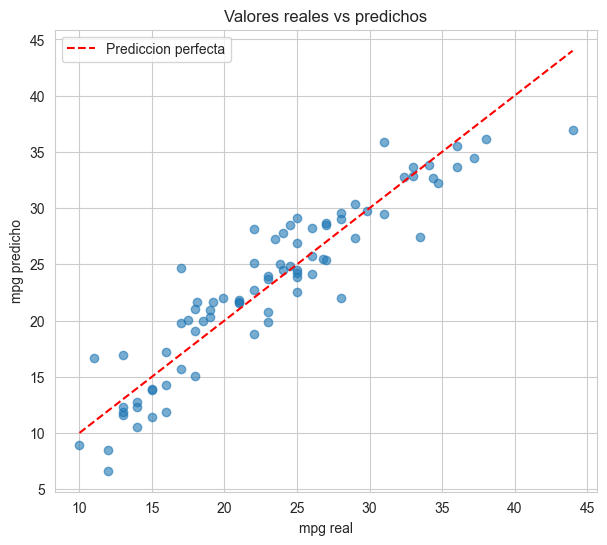

In [26]:
# Grafico: valores reales vs predichos
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Prediccion perfecta')
plt.xlabel('mpg real')
plt.ylabel('mpg predicho')
plt.title('Valores reales vs predichos')
plt.legend()
plt.show()

La mayoría de los puntos se agrupan cerca de la línea roja (predicción perfecta), lo que confirma el buen ajuste del modelo (R² ≈ 0.85). El error es un poco mayor en autos con consumo bajo (10-20 mpg), donde algunos puntos se alejan más de la línea, mientras que en el rango medio-alto (25-35 mpg) las predicciones son más precisas.

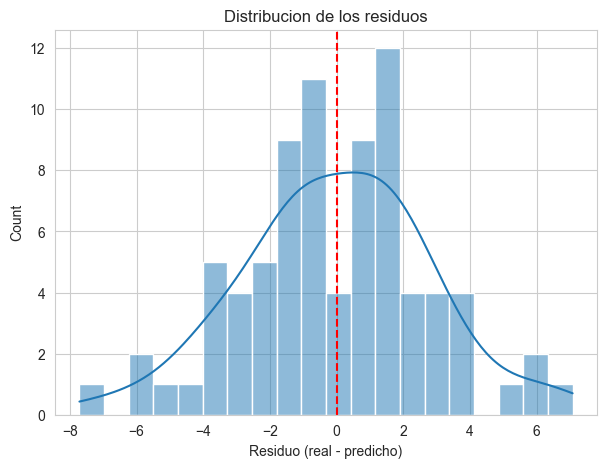

In [27]:
# Grafico: distribucion de los residuos (errores) Residuo = mpg real − mpg predicho datooo
residuos = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuos, kde=True, bins=20)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuo (real - predicho)')
plt.title('Distribucion de los residuos')
plt.show()

Los residuos se distribuyen de forma aproximadamente normal y centrada en cero, lo cual es una buena señal: indica que el modelo no tiene un sesgo sistemático (no sobreestima ni subestima de forma constante). La mayoría de los errores están entre -4 y 4 mpg, y solo unos pocos casos superan ese rango, lo que es consistente con el MAE de ~2.2 mpg obtenido en la evaluación.

### Interpretación de resultados
El modelo obtuvo un buen desempeño tanto en entrenamiento como en prueba, por lo que no presenta sobreajuste y puede realizar predicciones adecuadas. Además, explica aproximadamente el 85 % de la variabilidad del consumo de combustible.

La variable que más influye en la predicción es weight (peso del automóvil), seguida de horsepower y model_year. Asimismo, los vehículos europeos y japoneses tienden a presentar un mejor rendimiento de combustible que los estadounidenses. En general, el modelo cumple con el objetivo planteado de predecir el consumo de combustible de los automóviles.

### 5.2 Revisión del proceso

Se revisó el proceso de modelado en busca de errores metodológicos: no hubo fuga de datos (`mpg` fue excluido de `X` desde la construcción de datos), la división train/test se realizó antes de cualquier ajuste del modelo, y las métricas de train y test son consistentes entre sí. 

## 6. Despliegue

### 6.1 Plan de monitoreo y mantenimiento

Si se usaran datos de vehículos actuales, el modelo debería reentrenarse periódicamente, ya que la relación peso/consumo cambia con nuevas tecnologías (motores híbridos, eléctricos). Se recomienda monitorear el MAE en producción y reentrenar si el error crece de forma sostenida.

### 6.2 Informe final y revisión del proyecto

El proyecto cumplió el objetivo planteado: se identificaron weight y model_year como las variables más influyentes sobre el consumo, con un modelo simple e interpretable. Como aprendizaje, la regresión lineal fue suficiente para esta relación en su mayoría lineal; para datos con relaciones más complejas convendría comparar con modelos no lineales.

### Resultados Finales

El modelo de regresión lineal alcanzó un MAE de 2.22 mpg y un R² de 0.855 en el conjunto de prueba, sin señales de sobreajuste (el desempeño en train fue similar). Las variables más influyentes sobre el consumo fueron weight, power_to_weight y model_year: los autos más pesados y con motores relativamente más potentes consumen más combustible, mientras que los modelos más recientes son más eficientes. El modelo cumple el objetivo de negocio planteado en la sección 1: predecir el consumo con buena precisión e identificar qué características técnicas lo determinan.